`Machine Learning Clasificación y Regresión | Analía Elizabeth Gomory | Salta - 4400 - Argentina | 2025`

**by Analía Elizabeth Gomory**

* ae.gomory@gmail.com

* http://www.linkedin.com/in/elizabeth-gomory-9240b1217

* https://ae-gomory.itch.io

* https://github.com/ElizabethGomory

* https://www.credly.com/users/analia-gomory

* https://orcid.org/0009-0003-0498-7658

## Importación de librerías y Archivos

In [99]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn import svm
from sklearn.svm import SVR

import openpyxl as load_workbook
from pathlib import Path
import io
import sys
import os
import entrena_modelo_3 as entrena
sys.path.append(r'claseinfodf_2')
df = pd.read_csv("AmesHousing.csv")


## Normalización de datos

In [27]:
df.head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


In [28]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]  
missing_data

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
dtype: int64

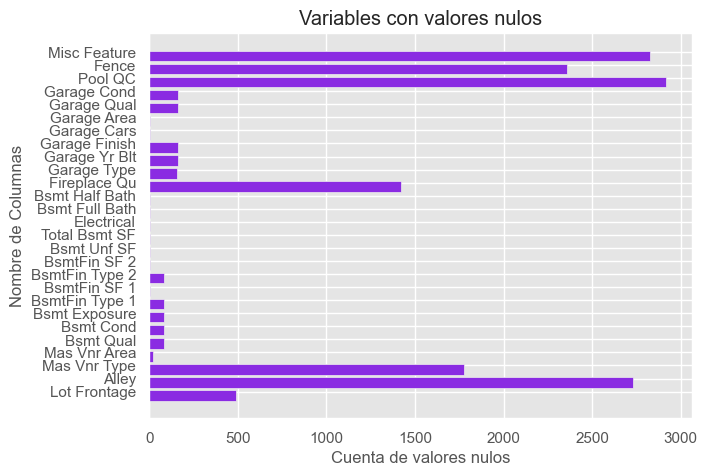

In [29]:
sns.set(font_scale=1)
matplotlib.style.use('ggplot')
labels = []
values = []
for col in df.columns[df.isnull().any()]:
    labels.append(col)
    values.append(df[col].isnull().sum())
ind = np.arange(len(labels))
ind
width=0.6
fig, ax = plt.subplots(figsize=(7,5))
rects = ax.barh(ind, np.array(values), color='blueviolet')
ax.set_yticks(ind+((width)/2.))
ax.set_yticklabels(labels, rotation='horizontal')
ax.set_xlabel("Cuenta de valores nulos")
ax.set_ylabel("Nombre de Columnas")
ax.set_title("Variables con valores nulos");

Limpieza de datos

In [ ]:
# Decidí eliminar solo las columnas con más del 35% de valores nulos, de lo contrario, me quedaría sin datos a entrenar
threshold = 0.35 * len(df)
columns_drop = missing_data[missing_data > threshold].index.tolist()
df_cleaned = df.drop(columns=columns_drop)

In [31]:
df_cleaned = df_cleaned.dropna()
df_cleaned = df.drop(columns=df.select_dtypes(include=['object', 'float64']).columns)
df_cleaned.shape

(2930, 28)

In [32]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Order            2930 non-null   int64
 1   PID              2930 non-null   int64
 2   MS SubClass      2930 non-null   int64
 3   Lot Area         2930 non-null   int64
 4   Overall Qual     2930 non-null   int64
 5   Overall Cond     2930 non-null   int64
 6   Year Built       2930 non-null   int64
 7   Year Remod/Add   2930 non-null   int64
 8   1st Flr SF       2930 non-null   int64
 9   2nd Flr SF       2930 non-null   int64
 10  Low Qual Fin SF  2930 non-null   int64
 11  Gr Liv Area      2930 non-null   int64
 12  Full Bath        2930 non-null   int64
 13  Half Bath        2930 non-null   int64
 14  Bedroom AbvGr    2930 non-null   int64
 15  Kitchen AbvGr    2930 non-null   int64
 16  TotRms AbvGrd    2930 non-null   int64
 17  Fireplaces       2930 non-null   int64
 18  Wood Dec

In [33]:
dfc=df_cleaned
count=dfc.nunique()
print((count*100)/dfc.shape[0])

Order              100.000000
PID                100.000000
MS SubClass          0.546075
Lot Area            66.894198
Overall Qual         0.341297
Overall Cond         0.307167
Year Built           4.027304
Year Remod/Add       2.081911
1st Flr SF          36.962457
2nd Flr SF          21.672355
Low Qual Fin SF      1.228669
Gr Liv Area         44.095563
Full Bath            0.170648
Half Bath            0.102389
Bedroom AbvGr        0.273038
Kitchen AbvGr        0.136519
TotRms AbvGrd        0.477816
Fireplaces           0.170648
Wood Deck SF        12.969283
Open Porch SF        8.600683
Enclosed Porch       6.245734
3Ssn Porch           1.058020
Screen Porch         4.129693
Pool Area            0.477816
Misc Val             1.296928
Mo Sold              0.409556
Yr Sold              0.170648
SalePrice           35.221843
dtype: float64


In [34]:
dfc=dfc.drop(['Order','PID','Lot Area','Gr Liv Area'],axis=1)

In [35]:
dfc['Houses more 1 Flr'] = dfc['1st Flr SF'] + dfc['2nd Flr SF']
dfc = dfc.drop(columns=['1st Flr SF', '2nd Flr SF'])
dfc.head()

,MS SubClass,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Low Qual Fin SF,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,...,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Houses more 1 Flr
0,20,6,5,1960,1960,0,1,0,3,1,...,62,0,0,0,0,0,5,2010,215000,1656
1,20,5,6,1961,1961,0,1,0,2,1,...,0,0,0,120,0,0,6,2010,105000,896
2,20,6,6,1958,1958,0,1,1,3,1,...,36,0,0,0,0,12500,6,2010,172000,1329
3,20,7,5,1968,1968,0,2,1,3,1,...,0,0,0,0,0,0,4,2010,244000,2110
4,60,5,5,1997,1998,0,2,1,3,1,...,34,0,0,0,0,0,3,2010,189900,1629


In [36]:
dfc.shape

(2930, 23)

<Axes: >

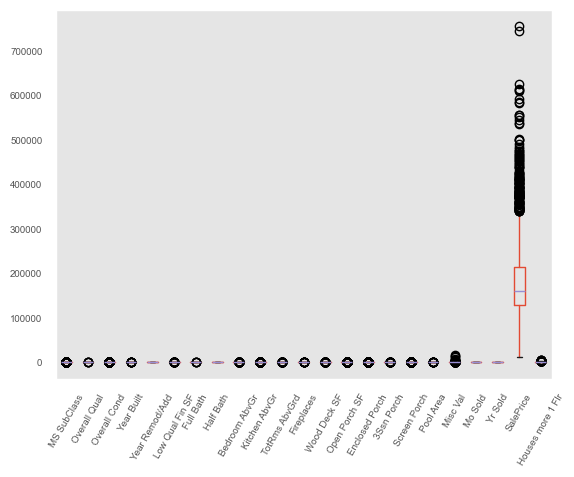

In [37]:
dfc.boxplot(grid=False,rot=60,fontsize=7)

Decidí eliminar aquellos outliers que superan los límites de los cuartiles

In [43]:
q1=dfc['SalePrice'].quantile(0.25)
q3=dfc['SalePrice'].quantile(0.75)
IQR=q3-q1
lower=q1-1.5*IQR
upper=q3 +1.5*IQR

In [42]:
upper_array=np.where(dfc['SalePrice']>=upper)[0]
lower_array=np.where(dfc['SalePrice']<=lower)[0]
print(lower_array)
print(upper_array)

[]
[  15   17   36   38   44   46   60   65   91  321  343  347  349  366
  367  421  422  423  427  429  430  431  432  433  434  436  442  447
  448  456  457  495  497  504  513  521  956  959  968 1010 1012 1050
 1051 1052 1053 1055 1056 1057 1058 1059 1060 1063 1064 1067 1068 1070
 1074 1102 1105 1106 1126 1158 1177 1425 1426 1537 1559 1587 1635 1636
 1637 1640 1641 1642 1684 1689 1690 1691 1693 1695 1696 1697 1699 1700
 1701 1706 1707 1708 1709 1760 1761 1763 1764 1767 1772 1780 1805 1860
 2096 2097 2099 2214 2245 2275 2329 2330 2331 2332 2333 2334 2335 2336
 2341 2379 2380 2382 2384 2391 2392 2395 2397 2398 2399 2400 2442 2445
 2446 2449 2450 2456 2461 2522 2666 2737 2883 2901 2902]


In [44]:
print(dfc.shape)
dfc.drop(index=upper_array, inplace=True)
dfc.drop(index=lower_array, inplace=True)
print(dfc.shape)

(2930, 23)
(2793, 23)


# Entrenamiento del Modelo

Entrenamiento y Validación

In [102]:
X = dfc.drop(columns=['SalePrice'])
y = dfc['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Entrenamiento SVR

In [100]:
kernels = ['linear', 'rbf', 'poly']
modelos = {}

for k in kernels:
    svr = SVR(kernel=k)  
    svr.fit(X_train, y_train)
    modelos[k] = svr
    print(f"Modelo SVR con kernel='{k}' entrenado.")


Modelo SVR con kernel='linear' entrenado.
Modelo SVR con kernel='rbf' entrenado.
Modelo SVR con kernel='poly' entrenado.


Predicción y Cálculo de MAE

In [103]:
mae_scores = {}
for k, model in modelos.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores[k] = mae
    print(f"MAE para kernel='{k}': {mae:.4f}")


MAE para kernel='linear': 21961.5690
MAE para kernel='rbf': 47691.6527
MAE para kernel='poly': 47619.4868


Comparación de modelor por Kernel

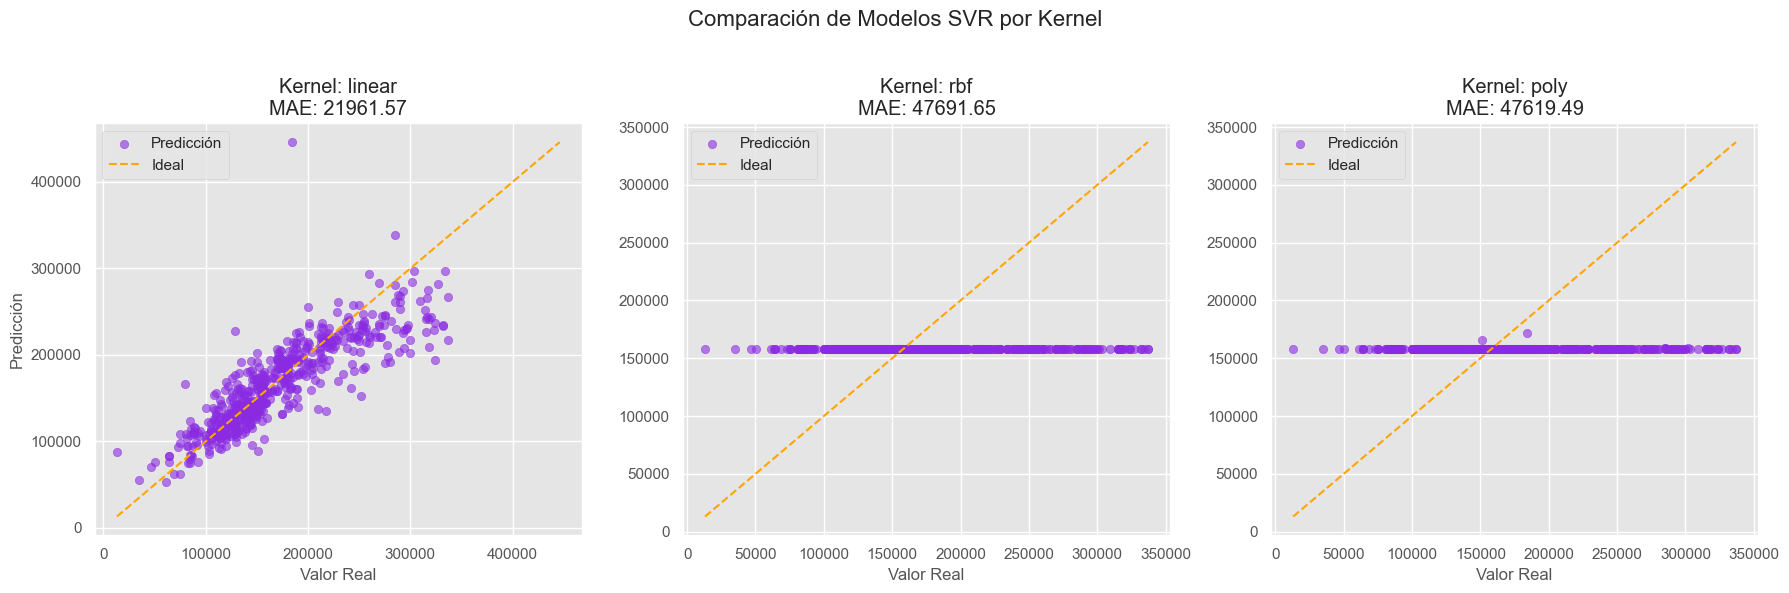

In [107]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

kernels = ['linear', 'rbf', 'poly']
modelos = {}
maes = {}

fig, axs = plt.subplots(1, 3, figsize=(18, 6))  

for i, k in enumerate(kernels):
    # Entrenamiento
    svr = SVR(kernel=k)
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)

    # Guardamos modelo y MAE
    modelos[k] = svr
    maes[k] = mean_absolute_error(y_test, y_pred)

    # Gráfico
    ax = axs[i]
    ax.scatter(y_test, y_pred, color='blueviolet', alpha=0.6, label='Predicción')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--', color='orange', label='Ideal')
    ax.set_title(f"Kernel: {k}\nMAE: {maes[k]:.2f}")
    ax.set_xlabel("Valor Real")
    if i == 0:
        ax.set_ylabel("Predicción")
    ax.legend()
    ax.grid(True)

plt.suptitle("Comparación de Modelos SVR por Kernel", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


*Según los resultados, el SVR con kernel lineal produjo el MAE más bajo en el conjunto de prueba. Por lo tanto, es el modelo recomendado, dado que minimiza el error medio absoluto.* 

Predicciones con el Modelo Lineal

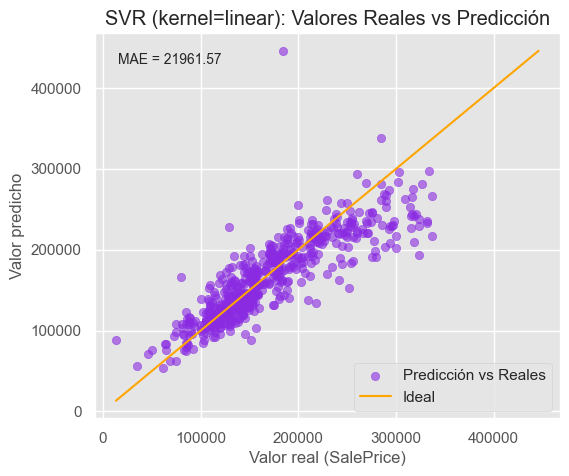

In [ ]:
y_pred_linear = modelos['linear'].predict(X_test)
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_linear, alpha=0.6, c='blueviolet', label='Predicción vs Reales')
# Línea ideal y=x
min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], '-', c='orange', label='Ideal')
plt.title('SVR (kernel=linear): Valores Reales vs Predicción')
plt.xlabel('Valor real (SalePrice)')
plt.ylabel('Valor predicho')
plt.legend()
plt.annotate(f'MAE = {mae_scores["linear"]:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, verticalalignment='top')
plt.grid(True)
plt.show()
